# Прогнозируем задержки самолётов


На основании доступных данных о рейсе нам нужно определить, будет ли он задержан на 15 минут.

## Импорт библиотек, установка констант

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import roc_auc_score

In [2]:
RANDOM_STATE = 111
DATASET_PATH = 'https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/flight_delays_train.csv'

## Загрузка и обзор данных

In [3]:
df = pd.read_csv(DATASET_PATH)

In [4]:
df.sample(5)

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
464,c-4,c-27,c-4,1512,XE,LIT,IAH,374,N
76969,c-4,c-23,c-7,1956,UA,ORD,MIA,1197,Y
35805,c-12,c-17,c-6,1041,XE,IAH,JAN,351,N
66711,c-10,c-27,c-4,1500,OO,PSC,SEA,172,N
33481,c-7,c-22,c-6,1223,UA,IAD,LAX,2288,N


## Обучение моделей

Разбейте данные
* на матрицу объект признак `X`, содержащую только числовые столбцы `DepTime`, `Distance`
* вектор с целевой переменной `y`, равный столбцу `dep_delayed_15min`, переведенном в 0 и 1 по правилу: 'Y' - 1, 'N' - 0.

In [5]:
# your code here
x = df[['DepTime', 'Distance']]
y = df['dep_delayed_15min'].map({'Y':1, 'N':0})

Обучите по кросс-валидации с тремя фолдами и метрикой *ROC-AUC* (`scoring='roc_auc'`) три модели с гиперпараметрами по умолчанию:
* решающее дерево
* случайный лес
* градиентный бустинг

Выведите на экран среднее качество по кросс-валидации каждой из моделей.

In [6]:
# your code here
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_cv = cross_val_score(dt, x, y, cv=3, scoring='roc_auc').mean()
dt_cv

np.float64(0.5792982351791407)

In [7]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_cv = cross_val_score(rf, x, y, cv=3, scoring='roc_auc').mean()
rf_cv

np.float64(0.6758129274941099)

In [8]:
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_cv = cross_val_score(gb, x, y, cv=3, scoring='roc_auc').mean()
gb_cv

np.float64(0.6992516986788738)

Выведите *bias* и *variance* каждой из моделей при помощи `bias_variance_decomp` из библиотеки `mlxtend`. Функция на вход ожидает получения тренировочных и тестовых данных, поэтому разобъем все данные на train и test.

Для ускорения вычислений
* возьмите только первые 1000 строк из тренировочных данных (`Xtrain[:1000], ytrain[:1000]`)
* поставьте `num_rounds = 50` в функции `bias_variance_decomp`

И не забудьте перевести `pd.dataframe` в `np.array` - так как библиотека умеет работать только с этим типом данных (`Xtrain.values` и так для всех объектов).

In [9]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.25, random_state=RANDOM_STATE)

In [10]:
from mlxtend.evaluate import bias_variance_decomp

# your code here

models = {'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
          'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
          'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)}

for name, model in models.items():
    avg_mse, avg_bias, avg_var = bias_variance_decomp(model, xtrain[:1000].values, ytrain[:1000].values,
                                                      xtest[:1000].values, ytest[:1000].values,
                                                      loss='mse',random_seed=RANDOM_STATE , num_rounds=50)
    print(f'model: {name}, loss:{avg_mse}, bias: {avg_bias}, variance: {avg_var}')

model: Decision Tree, loss:0.29738, bias: 0.1772996, variance: 0.12008039999999999
model: Random Forest, loss:0.24109999999999998, bias: 0.17899239999999997, variance: 0.0621076
model: Gradient Boosting, loss:0.21856, bias: 0.1690432, variance: 0.0495168


## Подбор гиперпараметров

Напомним, как мы действуем при подборе гиперпараметров:
* разбиваем данные на *train* и *test*
* на train по кросс-валидации при помощи `GridSearchCV` ищем наилучшие гиперпараметры модели
* оцениваем качество модели с наилучшими гиперпараметрами на *test*

Будем использовать 3 фолда при кросс-валидации, а метрику - *ROC-AUC* (`scoring='roc_auc'`).


Далее везде можно обучать модель на первых 10000 строк из обучающей выборки (так как всего два признака).

### 1. Подберите гиперпараметры для решающего дерева:
* `max_depth` (обязательно)
* `max_features` (обязательно)
* `criterion` (по желанию)
* `min_samples_split` (по желанию)
* `min_samples_leaf` (по желанию)

Диапазоны поиска гиперпараметров выбирайте самостоятельно.

Добейтесь качества *ROC-AUC* $>0.65$ на кросс-валидации.

In [11]:
# your code here
dt_params = {'max_depth': np.arange(2,20,3), 
          'max_features': [None,'sqrt', 'log2'],
          'min_samples_leaf': [1, 5, 10, 20],
          'min_samples_split': [2, 5, 10, 20]}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_params, cv=3, scoring='roc_auc', n_jobs=-1)
dt_gs.fit(xtrain[:10000], ytrain[:10000])

print("Best DT params:", dt_gs.best_params_)
print("Best DT CV score:", dt_gs.best_score_)

Best DT params: {'max_depth': np.int64(5), 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best DT CV score: 0.6900917507904426


Теперь обучите на **всех** тренировочных данных решающее дерево с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [12]:
# your code here
best_dt = dt_gs.best_estimator_
best_dt.fit(xtrain, ytrain)
print("DT Test ROC-AUC:", roc_auc_score(ytest, best_dt.predict_proba(xtest)[:, 1]))

DT Test ROC-AUC: 0.6996641842700552


### 2. Подберите гиперпараметры для случайного леса:
* `n_estimators` (обязательно)
* `max_depth` (обязательно)
* `max_features` (по желанию)
* `criterion` (по желанию)
* `min_samples_split` (по желанию)
* `min_samples_leaf` (по желанию)

Диапазоны поиска гиперпараметров выбирайте самостоятельно.

Добейтесь качества *ROC-AUC* $>0.65$ на кросс-валидации.

In [13]:
# your code here
rf_params = {'n_estimators': [50, 100, 200],
             'max_depth': [5, 10, 15],
             'max_features':[None, 'log2','sqrt'],
             'min_samples_leaf': [1, 5, 10, 20],
             'min_samples_split': [2, 5, 10, 20]}

rf_gs = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf_gs.fit(xtrain[:10000], ytrain[:10000])
print("Best RF params:", rf_gs.best_params_)
print("Best RF CV score:", rf_gs.best_score_)

Best RF params: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV score: 0.6991050934221793


Теперь обучите на **всех** тренировочных данных случайный лес с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [14]:
# your code here
best_rf = rf_gs.best_estimator_
best_rf.fit(xtrain, ytrain)
print(print("RF Test ROC-AUC:", roc_auc_score(ytest, best_rf.predict_proba(xtest)[:, 1])))

RF Test ROC-AUC: 0.702804462954219
None


### 3. Подберите гиперпараметры для градиентного бустинга:
* `n_estimators` (обязательно)
* `max_depth` (обязательно)
* `max_features` (по желанию)
* `criterion` (по желанию)
* `min_samples_split` (по желанию)
* `min_samples_leaf` (по желанию)

Диапазоны поиска гиперпараметров выбирайте самостоятельно.

Добейтесь качества *ROC-AUC* $>0.65$ на кросс-валидации.

In [15]:
# your code here
gb_params = {'n_estimators': [50, 100],
             'learning_rate': [0.01, 0.1],
             'max_depth': [3, 5, 7]
             }

gb_gs = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_params, cv=3, scoring='roc_auc', n_jobs=-1)
gb_gs.fit(xtrain, ytrain)
print("Best GB params:", gb_gs.best_params_)
print("Best GB CV score:", gb_gs.best_score_)

Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best GB CV score: 0.6981102725034334


Теперь обучите на **всех** тренировочных данных градиентный бустинг с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [16]:
# your code here
best_gb = gb_gs.best_estimator_
best_gb.fit(xtrain, ytrain)
print("GB Test ROC-AUC:", roc_auc_score(ytest, best_gb.predict_proba(xtest)[:, 1]))

GB Test ROC-AUC: 0.7062654785451475


Теперь поставьте `learning_rate = 0.01` (в десять раз меньше, чем по умолчанию) и увеличьте найденное число деревьев в 10 раз.

С этими изменениями обучите бустинг на трейне и выведите качество на тесте.

In [17]:
# your code here
best_n = gb_gs.best_params_['n_estimators']
final_gb = GradientBoostingClassifier(
    n_estimators=best_n * 10, 
    learning_rate=0.01, 
    max_depth=gb_gs.best_params_['max_depth'],
    random_state=RANDOM_STATE)

final_gb.fit(xtrain, ytrain)
gb_test_score = roc_auc_score(ytest, final_gb.predict_proba(xtest)[:, 1])
print(f"ROC-AUC на тесте (GB с LR=0.01): {gb_test_score}")

ROC-AUC на тесте (GB с LR=0.01): 0.707016536463723


## Размышления

Мы использовали для обучения очень много объектов и очень мало признаков, поэтому ансамбли моделей не смогли себя показать в полную мощь. Если задействовать больше характеристик полета, то и качество моделей может стать выше.

# Улучшение модели

Мы выкинули очень много колонок из начальной таблицы, но, возможно, они полезны для наших моделей.

Попробуем улучшить модель, использовав другие признаки.

In [18]:
df['dep_delayed_15min'] = df['dep_delayed_15min'].map({'Y' : 1, 'N' : 0})

Обработаем колонку месяц, оставив в ней только число - номер месяца.

Посмотрим на среднее количество задержек в каждом месяце.

In [19]:
df['Month'] = df['Month'].apply(lambda x: int(x.split('-')[1]))

print('average:', df['dep_delayed_15min'].mean())

df.groupby('Month')['dep_delayed_15min'].mean()

average: 0.19044


Month
1     0.190588
2     0.177406
3     0.194997
4     0.155328
5     0.153693
6     0.221892
7     0.238112
8     0.201925
9     0.156683
10    0.178584
11    0.170824
12    0.241258
Name: dep_delayed_15min, dtype: float64

Мы видим, что в некоторые месяцы (7 и 12) задержек довольно много, а в какие-то месяцы наоборот меньше. Так что признак может пригодиться!

В данных также есть интересный признак `UniqueCarrier` - это код авиакомпании-перевозчика.

Давайте посмотрим, связаны ли как-то задержки самолетов с авиакомпанией. Для этого выведем среднее число задержек и количество рейсов по каждой авиакомпании.

In [20]:
print('average:', df['dep_delayed_15min'].mean())

df.groupby('UniqueCarrier').agg({"dep_delayed_15min": ["mean", "count"]})

average: 0.19044


dep_delayed_15min       
                           mean  count
UniqueCarrier                         
AA                     0.187938   9418
AQ                     0.076923    234
AS                     0.243474   2222
B6                     0.213819   1838
CO                     0.181818   4334
DH                     0.161491    966
DL                     0.168922   8128
EV                     0.275318   3930
F9                     0.155070   1006
FL                     0.242185   3039
HA                     0.043307    762
HP                     0.142235   1378
MQ                     0.194545   7443
NW                     0.167890   6403
OH                     0.175882   4594
OO                     0.172801   7390
TZ                     0.143498    446
UA                     0.192263   6876
US                     0.167387   6482
WN                     0.213433  15082
XE                     0.173869   5901
YV                     0.224624   2128

Мы видим, что некоторые перевозчики довольно часто задерживают рейсы, а некоторые почти не задерживают. То есть знание об авиакомпании важно!


Код авиакомпании - это категориальный признак. В начале курса мы немного говорили про то, как можно кодировать такие признаки - вот [ссылка на соответствующий урок](https://stepik.org/lesson/806464/step/4?unit=809640).

Подход называется OneHot encoding. Напомним, в чем он состоит:
* мы создаем столько же колонок, сколько различных категорий в столбце
* далее для объекта ставим 1 в ту колонку, к категории которой он относится, а во все остальные колонки ставим 0

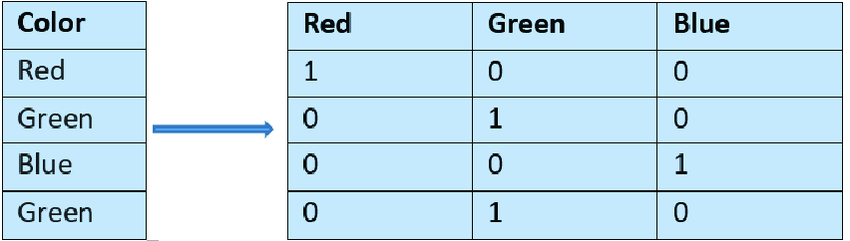

Заметим, что сумма значений в каждой строке равна 1 - то есть получили линейно-зависимые столбцы. Поэтому на практике создают на 1 колонку меньше, чем планировалось, чтобы избежать линейной зависимости.

Закодируем столбец `UniqueCarrier` при помощи OneHot encoding. В pandas этот метод называется get_dummies.

In [21]:
X = df[['Month','UniqueCarrier','DepTime','Distance']]
y = df['dep_delayed_15min']

X = pd.get_dummies(X, columns=['UniqueCarrier'], drop_first=True) # drop_first=True - выкидываем один столбец, чтобы избежать линейной зависимости
X.head()

,Month,DepTime,Distance,UniqueCarrier_AQ,UniqueCarrier_AS,UniqueCarrier_B6,UniqueCarrier_CO,UniqueCarrier_DH,UniqueCarrier_DL,UniqueCarrier_EV,...,UniqueCarrier_MQ,UniqueCarrier_NW,UniqueCarrier_OH,UniqueCarrier_OO,UniqueCarrier_TZ,UniqueCarrier_UA,UniqueCarrier_US,UniqueCarrier_WN,UniqueCarrier_XE,UniqueCarrier_YV
0,8,1934,732,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,4,1548,834,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,9,1422,416,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,11,1015,872,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,10,1828,423,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [22]:
print('Decision Tree:', cross_val_score(DecisionTreeClassifier(), X, y, cv=3, scoring='roc_auc').mean())
print('Random Forest:', cross_val_score(RandomForestClassifier(), X, y, cv=3, scoring='roc_auc').mean())
print('Gradient Boosting:', cross_val_score(GradientBoostingClassifier(), X, y, cv=3, scoring='roc_auc').mean())

Decision Tree: 0.5813292422775226
Random Forest: 0.6946681990507884
Gradient Boosting: 0.7129766554866984


Базовые модели показывают результаты по кросс-валидации чуть лучше! Ура!

Теперь вам необходимо подобрать оптимальные гиперпараметры модели так же, как вы делали в заданиях выше.

Так как информации о каждой авиакомпании не так много, то здесь для обучения лучше использовать все тренировочные данные, а не только первые 10000 строк.

In [23]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

### Подберите оптимальные гиперпараметры для Decision Tree.

In [24]:
# your code here
dt_params_new = {
    'max_depth': np.arange(3, 15, 2),
    'min_samples_leaf': [5, 10, 20, 50]
}

dt_gs_new = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_params_new, cv=3, scoring='roc_auc', n_jobs=-1)
dt_gs_new.fit(Xtrain, ytrain)

print("Best DT params:", dt_gs_new.best_params_)
print("Best DT CV score:", dt_gs_new.best_score_)

Best DT params: {'max_depth': np.int64(7), 'min_samples_leaf': 50}
Best DT CV score: 0.6940595246374671


Теперь обучите на **всех** тренировочных данных случайный лес с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [25]:
# your code here
best_dt_new = dt_gs_new.best_estimator_
best_dt_new.fit(Xtrain, ytrain)
print("DT ROC-AUC: ", roc_auc_score(ytest, best_dt_new.predict_proba(Xtest)[:, 1]))

DT ROC-AUC:  0.703446780770854


### Подберите оптимальные гиперпараметры для Random Forest.

In [26]:
# your code here
rf_params_new = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [10, 20]
}

rf_gs_new = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_params_new, cv=3, scoring='roc_auc', n_jobs=-1)
rf_gs_new.fit(Xtrain, ytrain)

print("Best RF params:", rf_gs_new.best_params_)
print("Best RF CV score:", rf_gs_new.best_score_)

Best RF params: {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 200}
Best RF CV score: 0.7139701786978093


Теперь обучите на **всех** тренировочных данных случайный лес с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [27]:
# your code here
best_rf_new = rf_gs_new.best_estimator_
best_rf_new.fit(Xtrain, ytrain)
print("RF ROC-AUC:", roc_auc_score(ytest, best_rf_new.predict_proba(Xtest)[:, 1]))

RF ROC-AUC: 0.7191079765779388


### Подберите оптимальные гиперпараметры для Random Forest.

Чтобы сверить часы с составителями задания, подберите оптимальные гиперпараметры бустинга:
* задайте n_estimators = 70
* ищите max_depth в диапазоне от 10 до 20 не включительно с шагом 3

In [28]:
# your code here
gb_params_new = {
    'n_estimators': [70],
    'max_depth': np.arange(10, 20, 3)
}

gb_gs_new = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), gb_params_new, cv=3, scoring='roc_auc', n_jobs=-1)
gb_gs_new.fit(Xtrain, ytrain)

print("Best GB params:", gb_gs_new.best_params_)
print("Best GB CV score:", gb_gs_new.best_score_)

Best GB params: {'max_depth': np.int64(10), 'n_estimators': 70}
Best GB CV score: 0.7138742633497857


Теперь обучите на **всех** тренировочных данных градиентный бустинг с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [29]:
# your code here
best_gb_new = gb_gs_new.best_estimator_
best_gb_new.fit(Xtrain, ytrain)
print("GB Test ROC-AUC (new features):", roc_auc_score(ytest, best_gb_new.predict_proba(Xtest)[:, 1]))

GB Test ROC-AUC (new features): 0.7244718102753153


Посмотрим на важность признаков у полученного бустинга.

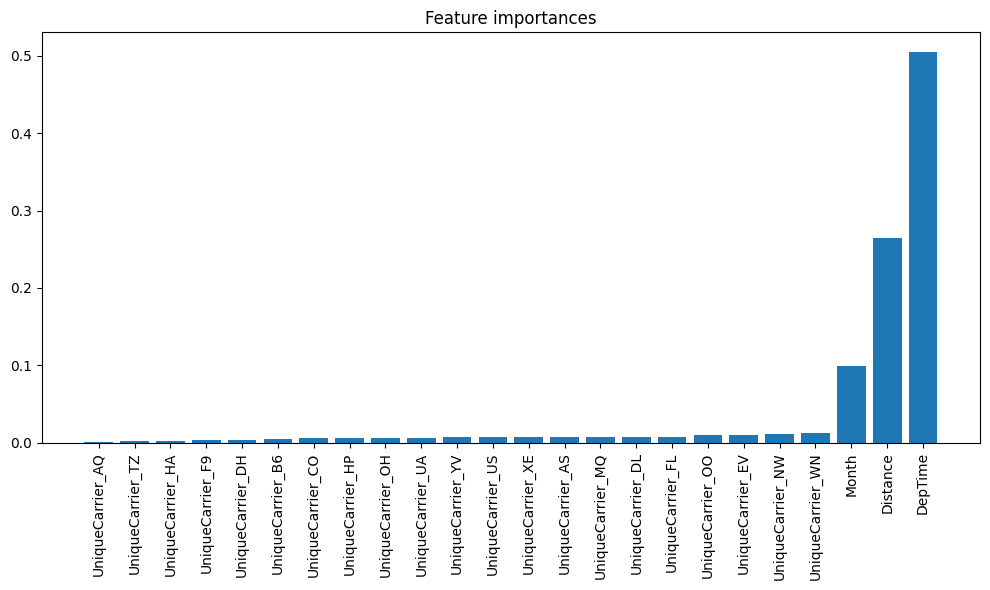

In [30]:
# в коде model - это модель (если назвали по-другому, то в этом кусочке измените model на свое название)
import matplotlib.pyplot as plt

model = best_gb_new

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(X.columns)[indices], rotation='vertical')
plt.tight_layout()
plt.show()